# AG-HYPOPT · Trial 03

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

[Two trials recorded. Trial 01 (sigma_ref 10.25, lr_mu 10.09, lr_gamma 0.52, gamma_anneal 0.10) scored 0.0981 +/- 0.0194 and showed the loss was mu-limited: mu underestimated in all eight experiments (-34% to -47%). Acting on that, trial 02 raised lr_mu to 25.36 (sigma_ref 6.84, lr_gamma 0.44, gamma_anneal 0.20) and scored 0.0246 +/- 0.0094, the current best (~4x better): mu rel RMSE fell 39.8% -> 17.5% and gamma 19.5% -> 13.7%. The residual error is now concentrated at low signal: both Trans05 points have mu about -31%, and 3nW Trans05 has gamma -32%; high-transmission mu is nearly unbiased. gamma (13.7%) is now a comparable error source to mu (17.5%). The campaign is still in the uniform-design phase (2/5 done), so cell 2 samples 10 candidates uniformly again.]


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_03'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 20    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = uniform  (2/5 trials)
ID |     ei | params
 1 |      - | {"gamma_anneal": 0.06423687535771827, "lr_gamma": 0.3894484052768798, "lr_mu": 25.031861630159923, "sigma_ref": 16.643240721287356}
 2 |      - | {"gamma_anneal": 0.07059648168029939, "lr_gamma": 0.5465015521891791, "lr_mu": 16.976282453520852, "sigma_ref": 8.19477829274157}
 3 |      - | {"gamma_anneal": 0.5509328635569108, "lr_gamma": 0.29093761593712275, "lr_mu": 14.78070476239155, "sigma_ref": 15.334803652427274}
 4 |      - | {"gamma_anneal": 0.3229710153106333, "lr_gamma": 0.6694388571505125, "lr_mu": 23.445944682304006, "sigma_ref": 24.125345096721972}
 5 |      - | {"gamma_anneal": 0.2131508728115936, "lr_gamma": 0.71883776566386, "lr_mu": 22.405399916753886, "sigma_ref": 10.854414980249743}
 6 |      - | {"gamma_anneal": 0.001117562631627128, "lr_gamma": 0.9787682198131302, "lr_mu": 12.460030575421891, "sigma_ref": 11.279720040686737}
 7 |      - | {"gamma_anneal": 0.6687833028338679, "lr_gamma": 0.66813035191272

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

[Best so far is trial 02 (0.0246, lr_mu 25.36, sigma_ref 6.84, lr_gamma 0.44, gamma_anneal 0.20). The two trials show the dominant positive effect is a large lr_mu; with mu now much closer, gamma (rel RMSE 13.7%, worst at 3nW Trans05 -32%) is a comparable residual error and has only been weakly tuned (lr_gamma 0.52 then 0.44). The most informative next step is therefore to raise lr_gamma while staying in the proven high-lr_mu regime. Candidate 10 (lr_mu 23.05, sigma_ref 9.37, lr_gamma 0.79, gamma_anneal 0.22) does that: near-best lr_mu with a moderate sigma_ref, but lr_gamma ~1.8x trial 02, testing whether the residual gamma error responds to faster gamma learning. The alternative candidate 1 (lr_mu 25.03, sigma_ref 16.64) probes sigma_ref instead, and candidates 6/9 pair a high lr_gamma with the wrong (low) lr_mu regime. I choose candidate 10.]


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 10              # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.22362231799306856, 'lr_gamma': 0.7934053440554643, 'lr_mu': 23.054120203552937, 'sigma_ref': 9.374308491376091}
Running  1nW Trans05 ... 

μ 9.39 -> 5.61 | γ 8.5 -> 7.21 | NLL 1.19


Running  1nW Trans20 ... 

μ 17.32 -> 12.94 | γ 8.5 -> 10.09 | NLL 2.89


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 84.11 | γ 14.1 -> 14.94 | NLL 3.63


Running 3nW Trans100 ... 

μ 175.71 -> 134.64 | γ 14.1 -> 14.68 | NLL 3.20



Total: 6.7 min


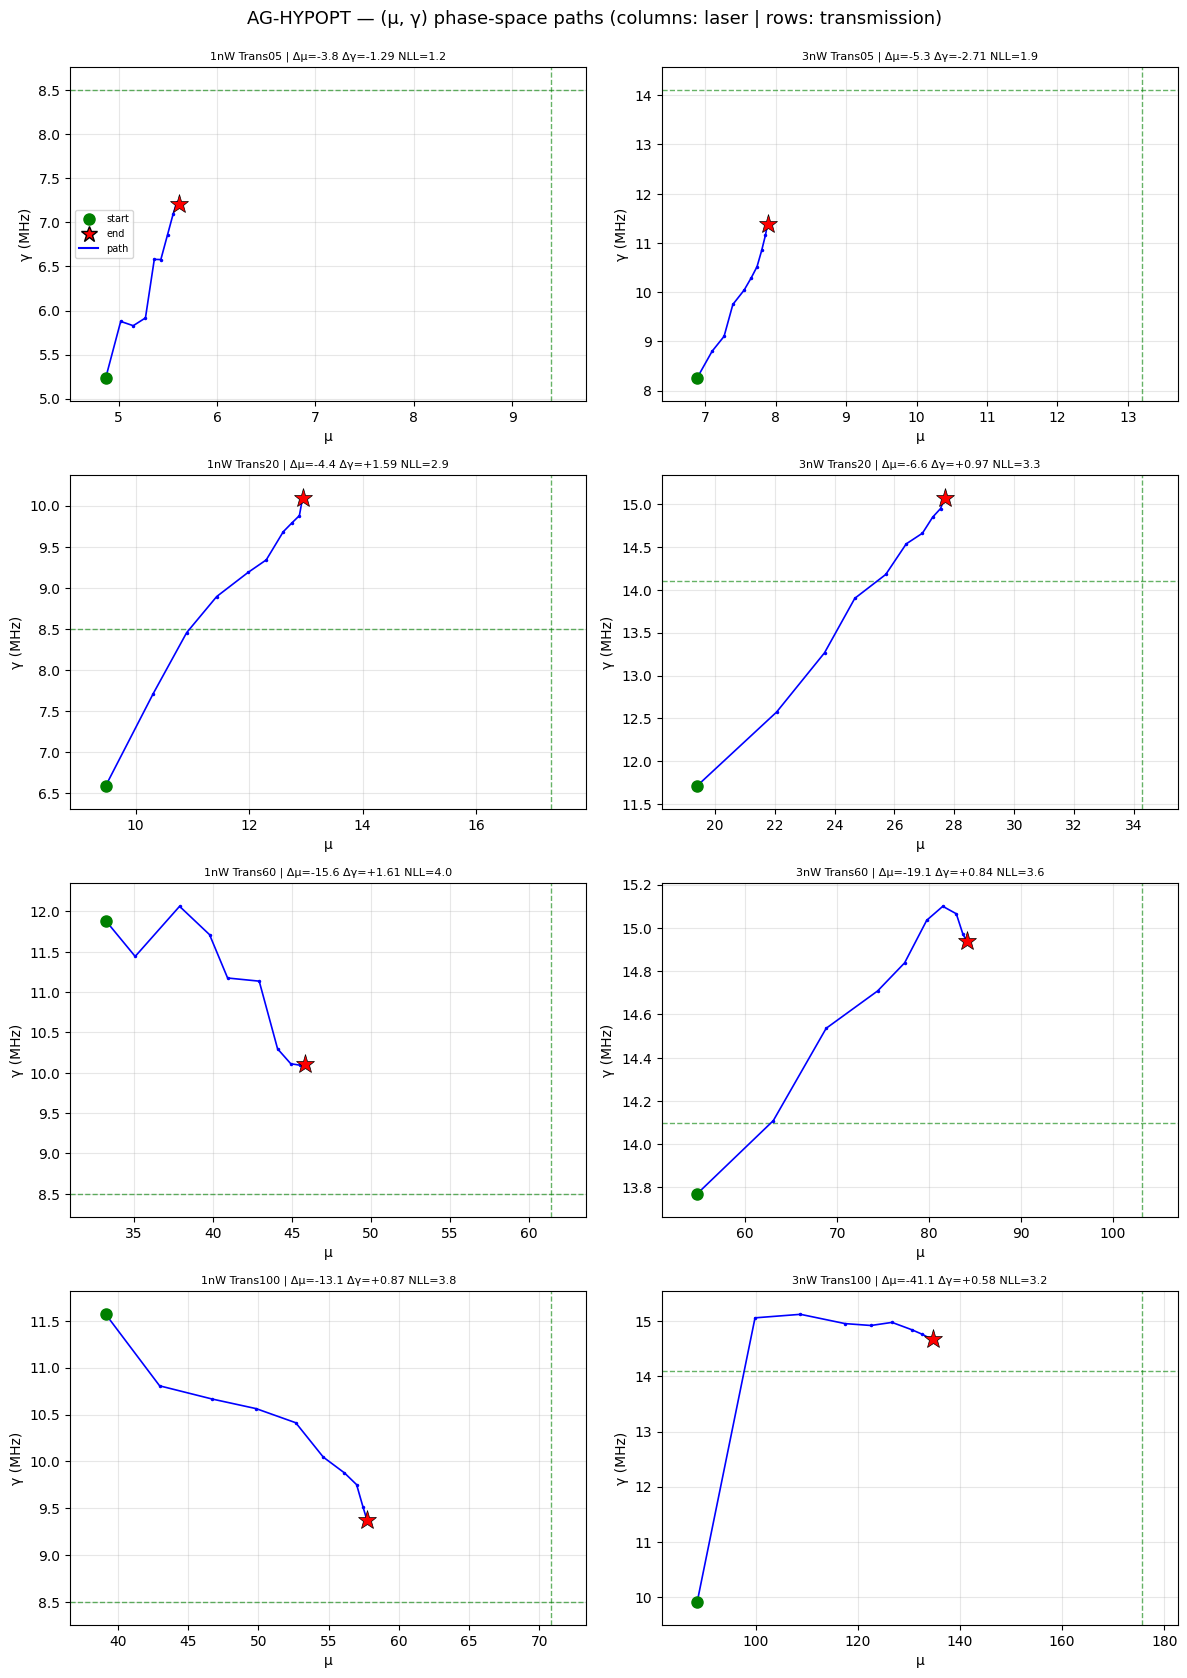

trial finished in 6.8 min
objective = 0.0477 ± 0.0122
exp           μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05     9.39    5.61   -40.3 |     8.50    7.21   -15.2
1nW Trans20    17.32   12.94   -25.3 |     8.50   10.09   +18.7
1nW Trans60    61.37   45.79   -25.4 |     8.50   10.11   +18.9
1nW Trans100   70.82   57.74   -18.5 |     8.50    9.37   +10.2
3nW Trans05    13.20    7.89   -40.3 |    14.10   11.39   -19.3
3nW Trans20    34.28   27.67   -19.3 |    14.10   15.07    +6.9
3nW Trans60   103.20   84.11   -18.5 |    14.10   14.94    +6.0
3nW Trans100  175.71  134.64   -23.4 |    14.10   14.68    +4.1

μ: RMSE 17.925 (rel 27.7%, bias -13.612) | γ: RMSE 1.452 (rel 13.7%, bias +0.305)


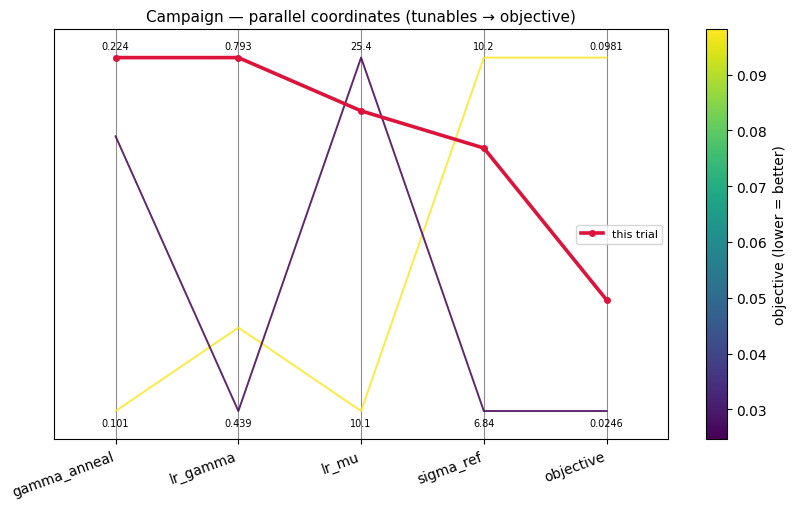

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 03 (sigma_ref 9.37, lr_mu 23.05, lr_gamma 0.79, gamma_anneal 0.22) ran 6.8 min and scored 0.0477 +/- 0.0122, worse than trial 02 (0.0246) but still better than trial 01 (0.0981). Its purpose was to test a higher lr_gamma at near-best mu settings. gamma did not improve at all: rel RMSE is 13.7%, identical to trial 02 (and the bias flips sign, +0.31 vs -0.35), despite lr_gamma 0.44 -> 0.79. mu regressed instead: rel RMSE 17.5% -> 27.7% (bias -5.8 -> -13.6), with the high-transmission points that trial 02 had nearly fixed slipping back (1nW Trans60 -25% vs -7%, 3nW Trans100 -23% vs -12%) and both Trans05 points worse at -40%. Relative to trial 02 this config lowered lr_mu (25.36 -> 23.05) and raised sigma_ref (6.84 -> 9.37) alongside lr_gamma, so the mu regression is attributable to the mu-regime change, not to gamma. gamma stays flat at ~13.7% across trials 02 and 03, so it is not lr_gamma-limited; mu remains the main lever and the best mu regime seen so far is trial 02's.

**Summary:** Trial 03 (sigma_ref 9.37, lr_mu 23.05, lr_gamma 0.79, gamma_anneal 0.22) scored 0.0477 +/- 0.0122, worse than trial 02: raising lr_gamma left gamma flat (13.7%) while the accompanying mu-regime change pushed mu rel RMSE back up to 27.7%.
**Key insight:** gamma (13.7%) is insensitive to lr_gamma, whereas mu tracks lr_mu / sigma_ref; trial 02's high-lr_mu, low-sigma_ref regime remains the best.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
[Notes for Anuar: none this trial.]


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = 'Trial 03 (sigma_ref 9.37, lr_mu 23.05, lr_gamma 0.79, gamma_anneal 0.22) scored 0.0477 +/- 0.0122, worse than trial 02: raising lr_gamma left gamma flat (13.7%) while the accompanying mu-regime change pushed mu rel RMSE back up to 27.7%.'
KEY_INSIGHT = 'gamma (13.7%) is insensitive to lr_gamma, whereas mu tracks lr_mu / sigma_ref; trial 02 high-lr_mu, low-sigma_ref regime remains the best.'


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_03 | current best: trial_02


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_04.ipynb. Open it and follow its cells from the top.
